# 1 Split images into train and validation folders

In [1]:
# Unzip images to a custom data folder
import zipfile

zip_path = "data.zip"  # coloque o nome correto do seu zip
extract_path = "custom_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extração concluída!")

Extração concluída!


In [2]:
from pathlib import Path
import subprocess
import sys

script_path = Path("train_val_split.py")
data_path = Path("custom_data")

if not script_path.exists():
    raise FileNotFoundError(f"Script não encontrado: {script_path.resolve()}")
if not data_path.exists():
    raise FileNotFoundError(f"Pasta de dados não encontrada: {data_path.resolve()}")

subprocess.run(
    [
        sys.executable,
        str(script_path),
        f"--datapath={data_path.resolve()}",
        "--train_pct=0.9",
    ],
    check=True,
 )
print("Split train/validation concluído com sucesso.")

Split train/validation concluído com sucesso.


# 2.&nbsp;Configure Training


In [3]:
# Python function to automatically create data.yaml config file
from pathlib import Path
import yaml

def create_data_yaml(path_to_classes_txt, path_to_data_yaml, dataset_root):
    # Read classes.txt to get class names
    if not path_to_classes_txt.exists():
        print(f"classes.txt file not found! Expected at: {path_to_classes_txt}")
        return

    with path_to_classes_txt.open('r', encoding='utf-8') as f:
        classes = [line.strip() for line in f if line.strip()]

    number_of_classes = len(classes)

    # Create data dictionary for YOLO
    data = {
        'path': str(dataset_root.resolve()),
        'train': 'train/images',
        'val': 'validation/images',
        'nc': number_of_classes,
        'names': classes
    }

    # Write data to YAML file
    with path_to_data_yaml.open('w', encoding='utf-8') as f:
        yaml.dump(data, f, sort_keys=False, allow_unicode=True)

    print(f"Created config file at {path_to_data_yaml.resolve()}")

# Define paths and run function
project_root = Path.cwd()
path_to_classes_txt = project_root / 'custom_data' / 'classes.txt'
path_to_data_yaml = project_root / 'data.yaml'
dataset_root = project_root / 'data'

create_data_yaml(path_to_classes_txt, path_to_data_yaml, dataset_root)

print('\nFile contents:\n')
print(path_to_data_yaml.read_text(encoding='utf-8'))

Created config file at C:\Users\enzoa\Desktop\faculdade\estágio\teste dataset empresa\yolo\data.yaml

File contents:

path: C:\Users\enzoa\Desktop\faculdade\estágio\teste dataset empresa\yolo\data
train: train/images
val: validation/images
nc: 11
names:
- C+
- C-
- R+
- R-
- R/CFaltante
- Soldagem+
- SoldagemCurtoCircuito
- SoldagemFaltando
- U+
- U-
- UFaltante



# 3.&nbsp;Train Model

In [4]:
from pathlib import Path
import subprocess
import sys

data_yaml = Path('data.yaml')
if not data_yaml.exists():
    raise FileNotFoundError(f'data.yaml não encontrado em: {data_yaml.resolve()}')

print('Iniciando treinamento... Aguarde, o progresso será exibido abaixo:\n')

# Executa o comando YOLO com output em tempo real
process = subprocess.Popen(
    [
        'yolo',
        'detect',
        'train',
        f'data={data_yaml.resolve()}',
        'model=yolo11s.pt',
        'epochs=100',
        'imgsz=640',
        'device=0',
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    universal_newlines=True,
    bufsize=1,
 )

# Exibe o output em tempo real
for line in process.stdout:
    print(line, end='')
    sys.stdout.flush()

process.wait()

if process.returncode != 0:
    raise RuntimeError(f'Treinamento falhou com código de retorno {process.returncode}')

print('\n\nTreinamento concluído com sucesso!')

Iniciando treinamento... Aguarde, o progresso será exibido abaixo:




New https://pypi.org/project/ultralytics/8.4.31 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.19  Python-3.10.19 torch-2.10.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8192MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\enzoa\Desktop\faculdade\estgio\teste dataset empresa\yolo\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, mo

# 4.&nbsp;Test Model

In [5]:
from pathlib import Path
import subprocess
import sys

validation_images = Path('data/validation/images')
if not validation_images.exists():
    raise FileNotFoundError(f'Pasta de validação não encontrada: {validation_images.resolve()}')

best_candidates = sorted(
    Path('runs/detect').glob('*/weights/best.pt'),
    key=lambda p: p.stat().st_mtime,
    reverse=True,
 )
if not best_candidates:
    raise FileNotFoundError('Nenhum best.pt encontrado em runs/detect/*/weights')

best_model = best_candidates[0]
print(f'Usando modelo: {best_model.resolve()}\n')
print('Iniciando predição... Progresso:\n')

# Executa o comando YOLO com output em tempo real
process = subprocess.Popen(
    [
        'yolo',
        'detect',
        'predict',
        f'model={best_model.resolve()}',
        f'source={validation_images.resolve()}',
        'save=True',
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    universal_newlines=True,
    bufsize=1,
 )

# Exibe o output em tempo real
for line in process.stdout:
    print(line, end='')
    sys.stdout.flush()

process.wait()

if process.returncode != 0:
    raise RuntimeError(f'Predição falhou com código de retorno {process.returncode}')

print('\n\nPredição concluída com sucesso!')

Usando modelo: C:\Users\enzoa\Desktop\faculdade\estágio\teste dataset empresa\yolo\runs\detect\train\weights\best.pt

Iniciando predição... Progresso:

Ultralytics 8.4.19  Python-3.10.19 torch-2.10.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8192MiB)
YOLO11s summary (fused): 101 layers, 9,417,057 parameters, 0 gradients, 21.3 GFLOPs

image 1/11 C:\Users\enzoa\Desktop\faculdade\estgio\teste dataset empresa\yolo\data\validation\images\0ce50974-17.png: 288x640 2 C+s, 7 R+s, 4 R/CFaltantes, 1 U+, 85.9ms
image 2/11 C:\Users\enzoa\Desktop\faculdade\estgio\teste dataset empresa\yolo\data\validation\images\1f733dcc-51a.jpg: 544x640 10 C+s, 10 R+s, 10 R/CFaltantes, 10 Soldagem+s, 8 SoldagemFaltandos, 2 U+s, 1 UFaltante, 75.2ms
image 3/11 C:\Users\enzoa\Desktop\faculdade\estgio\teste dataset empresa\yolo\data\validation\images\2f389590-1b.jpg: 640x576 14 R+s, 71.3ms
image 4/11 C:\Users\enzoa\Desktop\faculdade\estgio\teste dataset empresa\yolo\data\validation\images\45408846-2a.jpg: 640x544 (no d

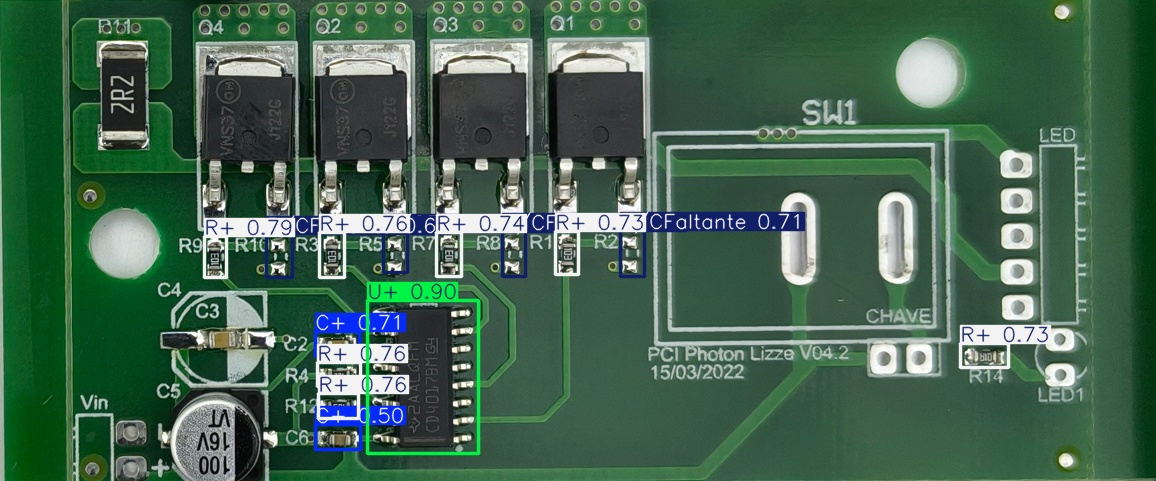

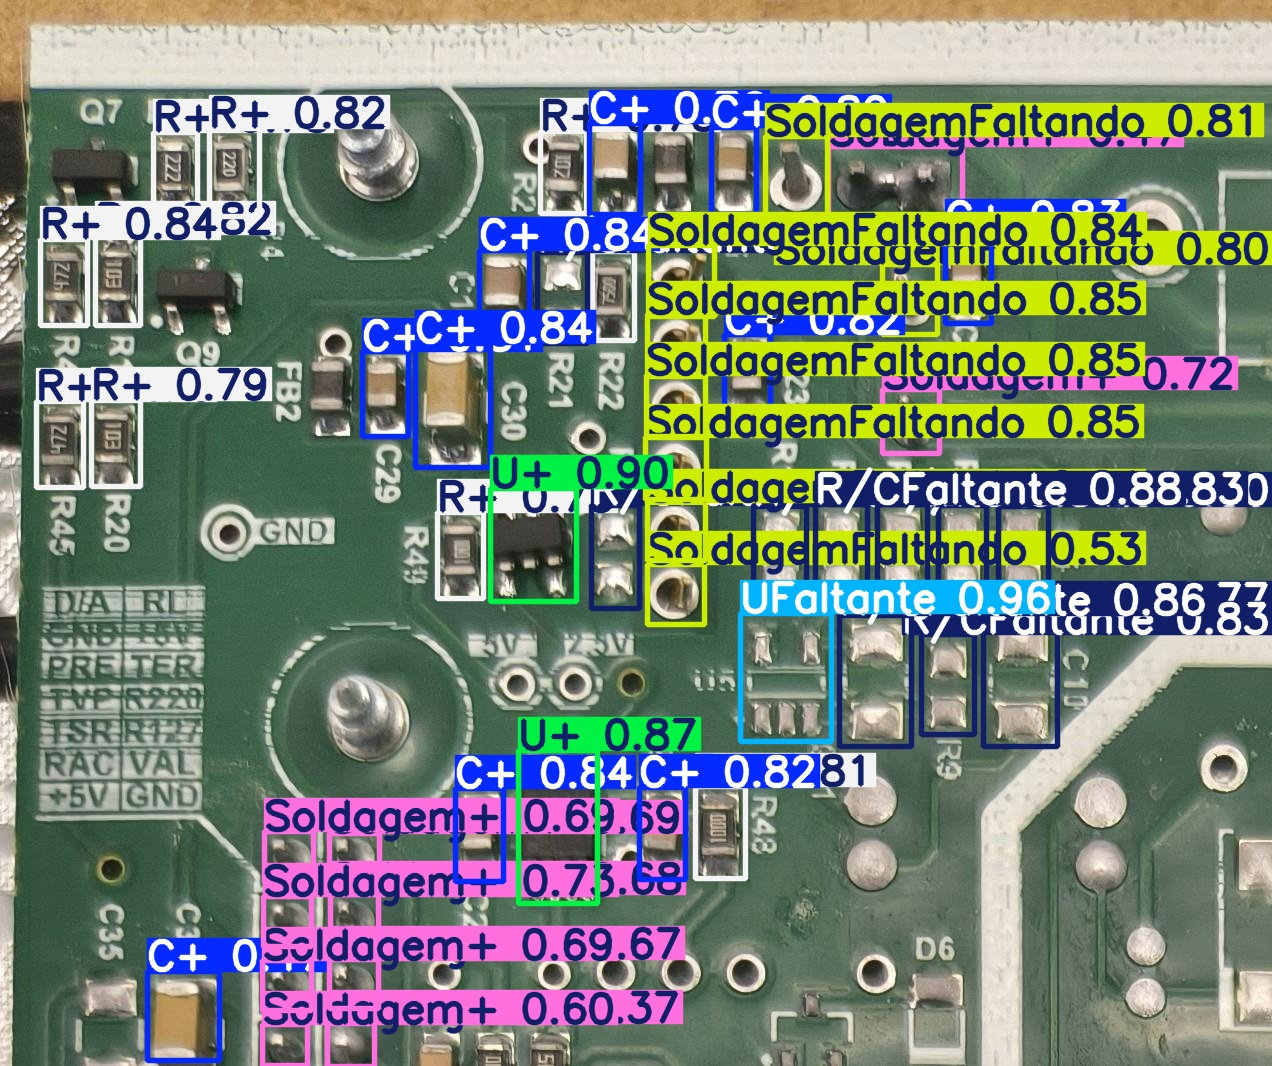

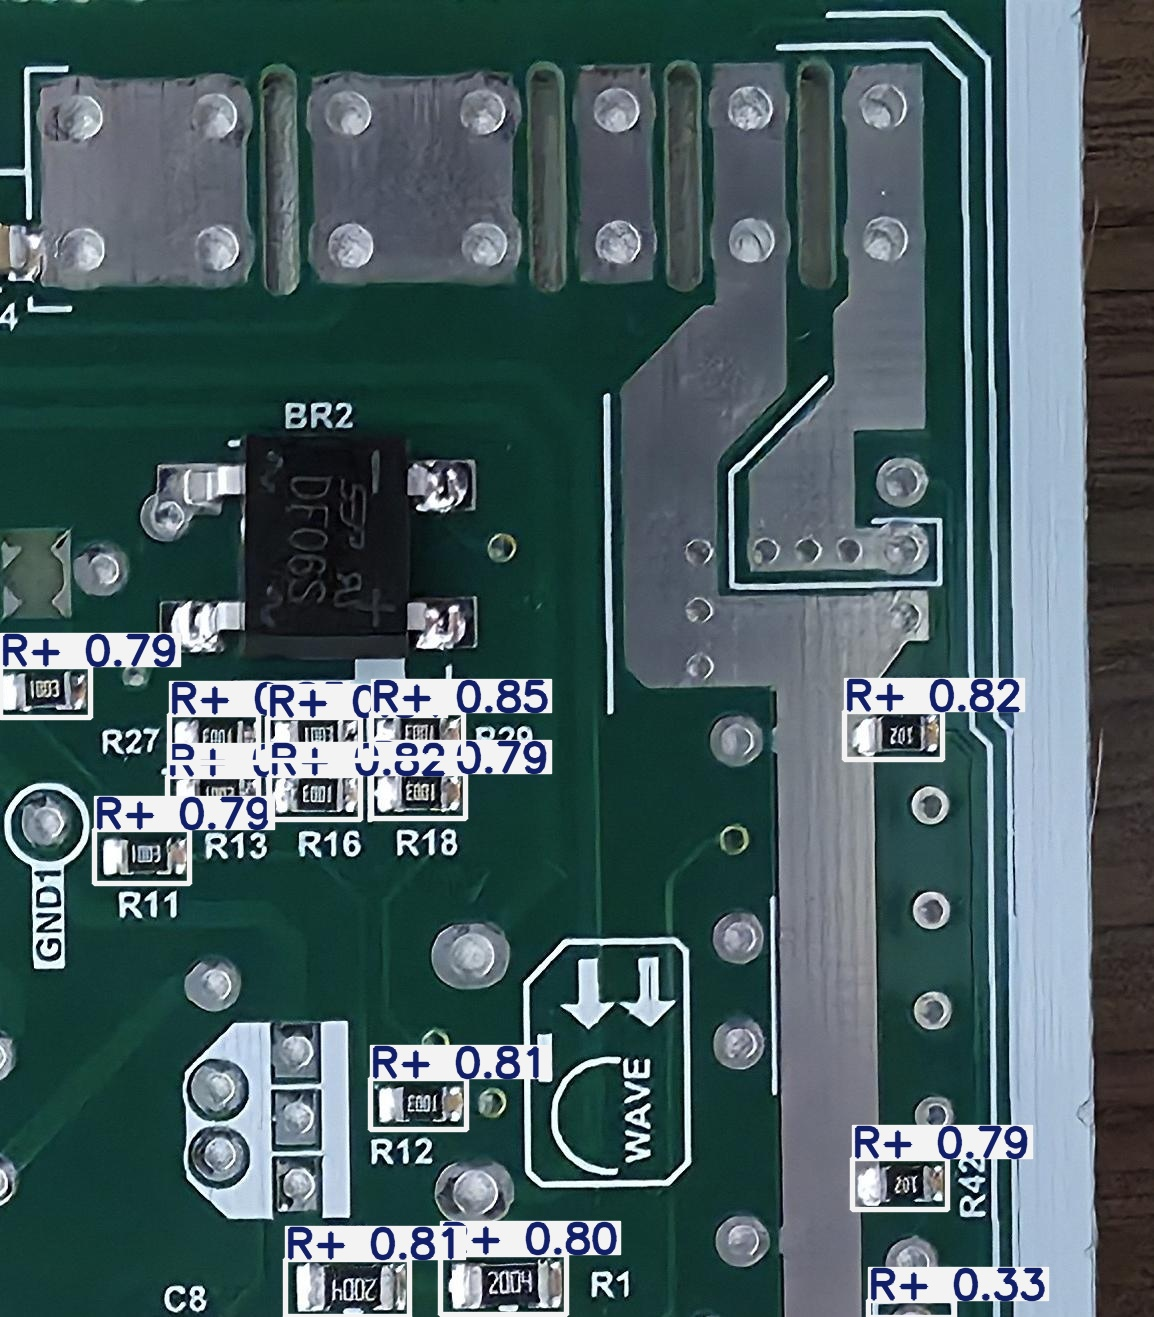

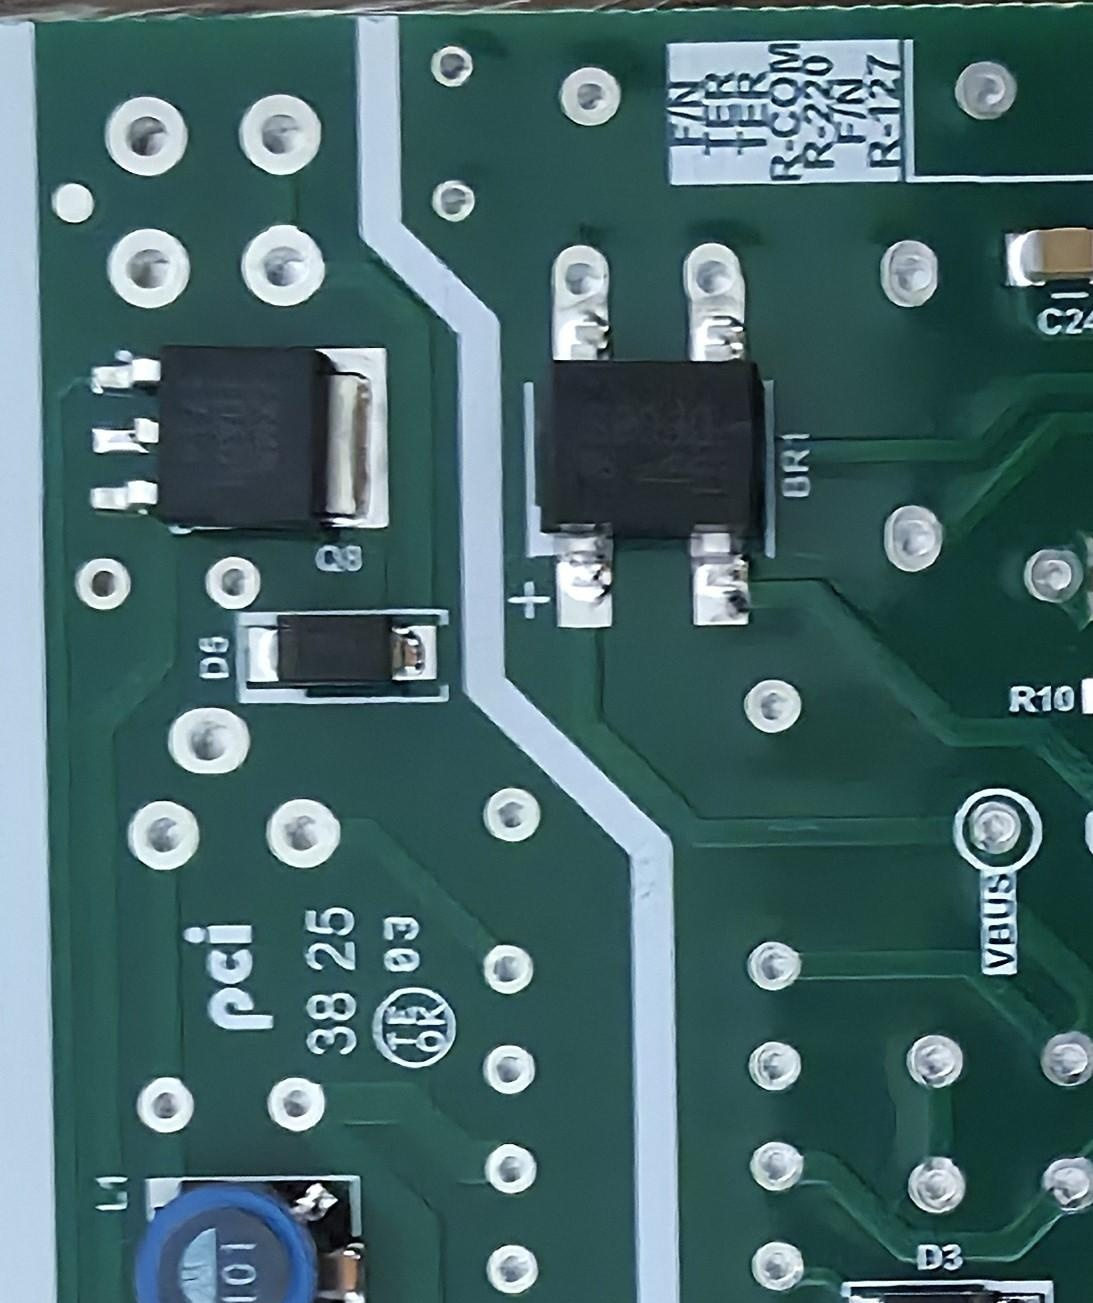

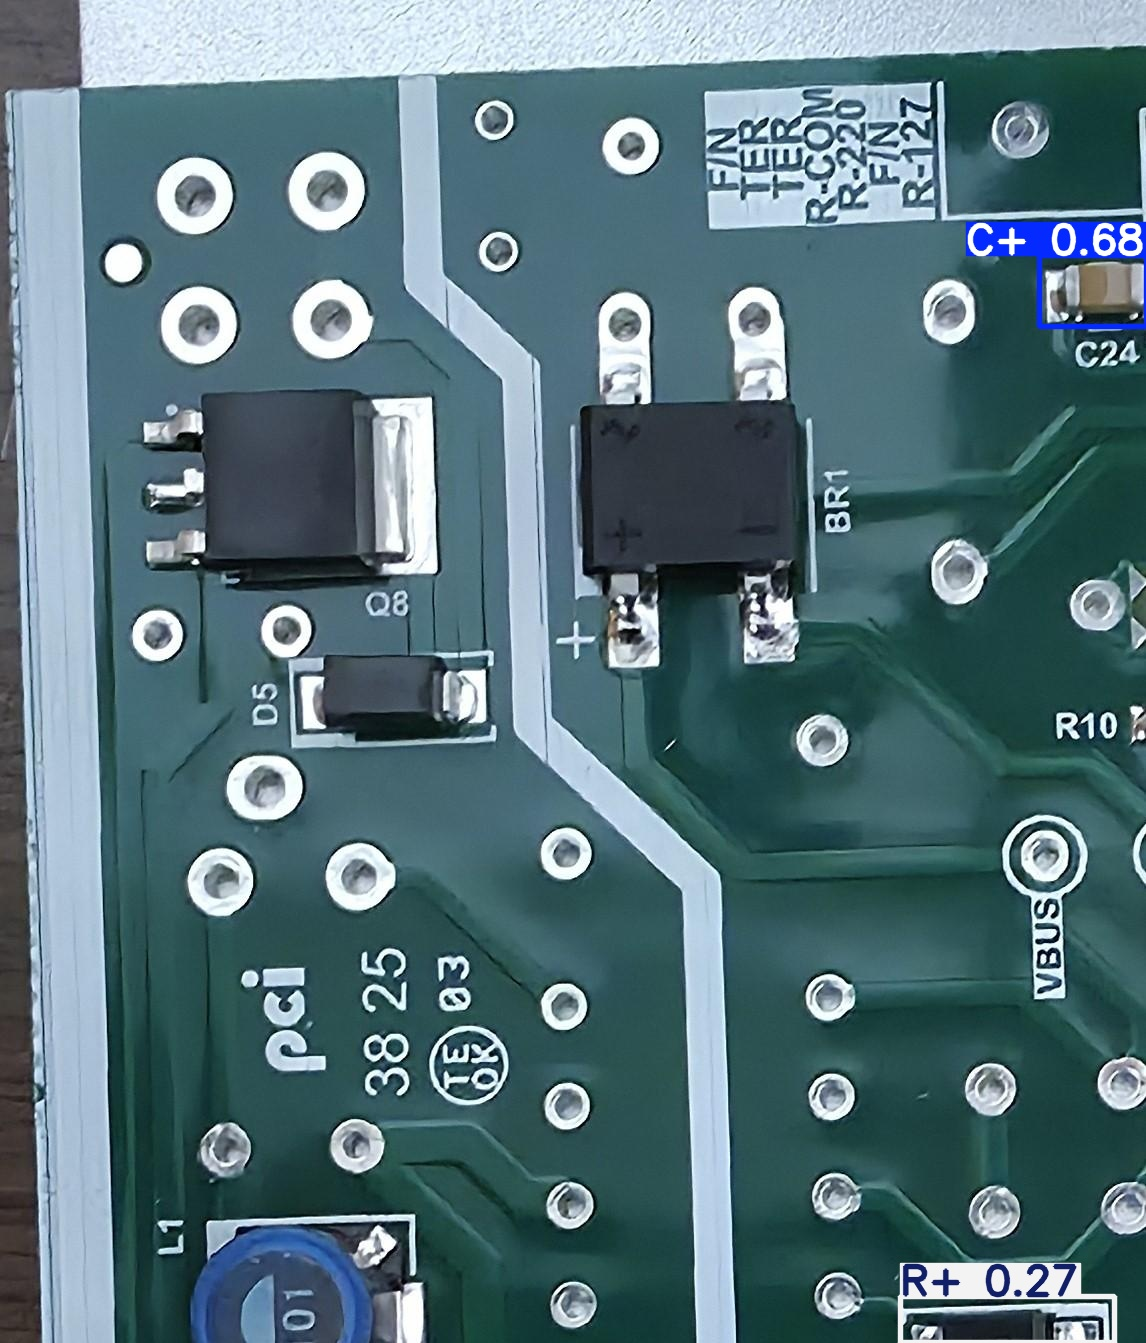

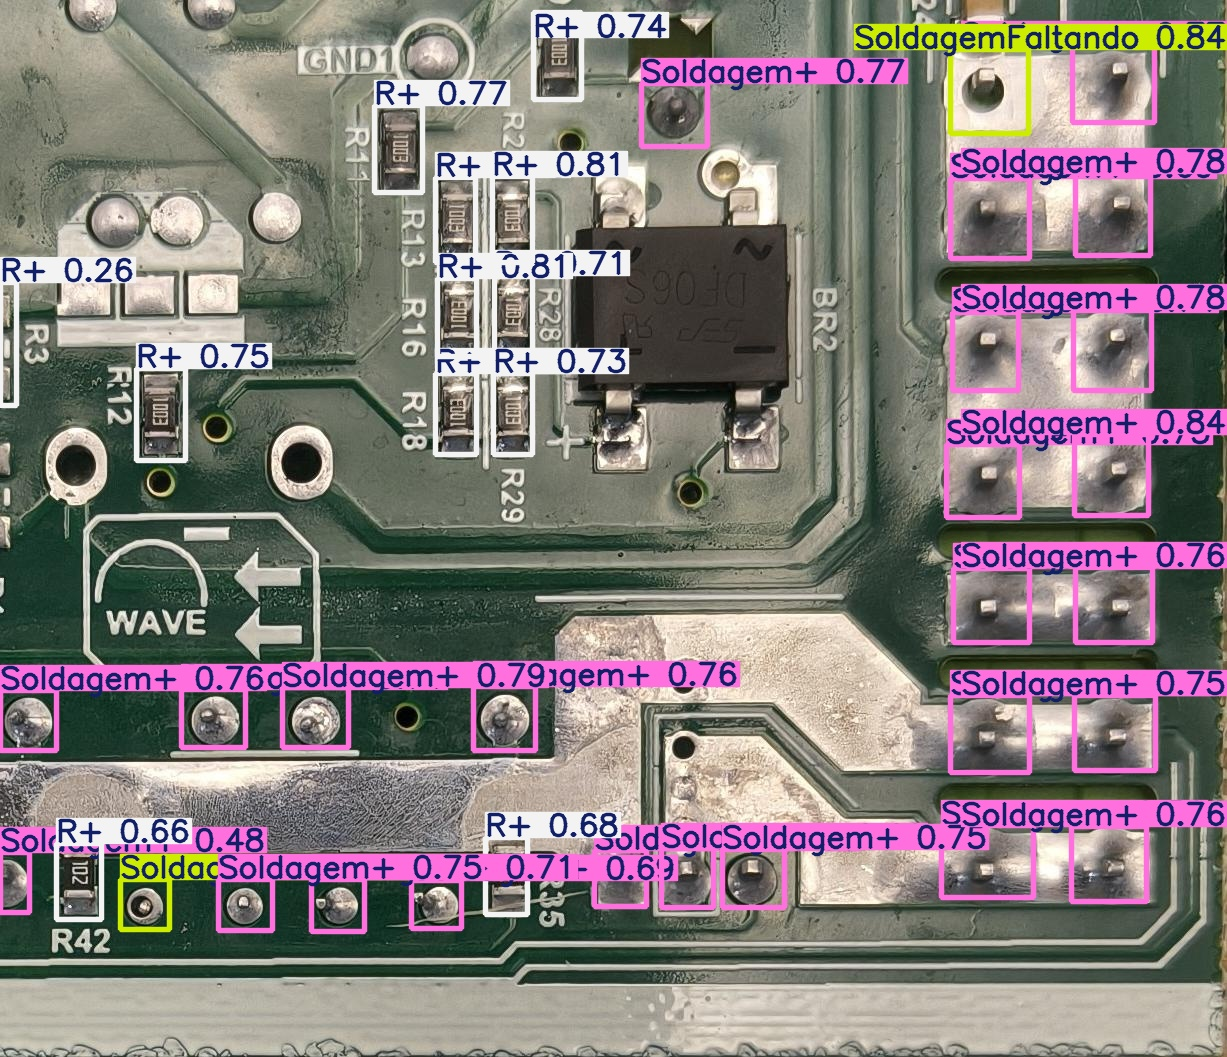

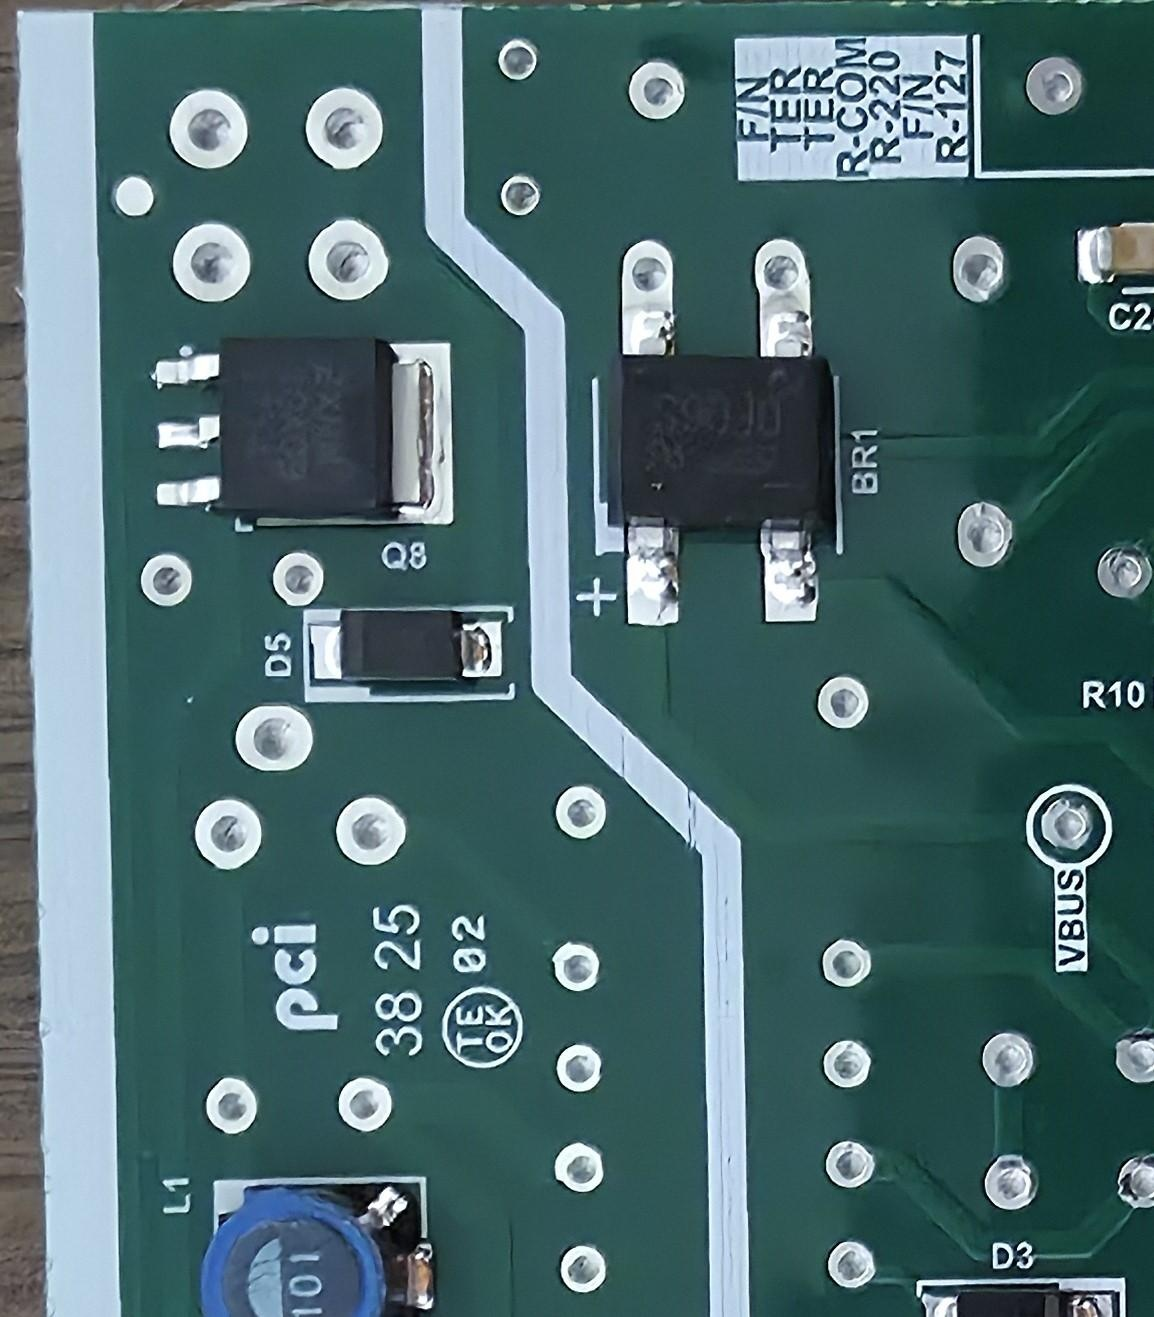

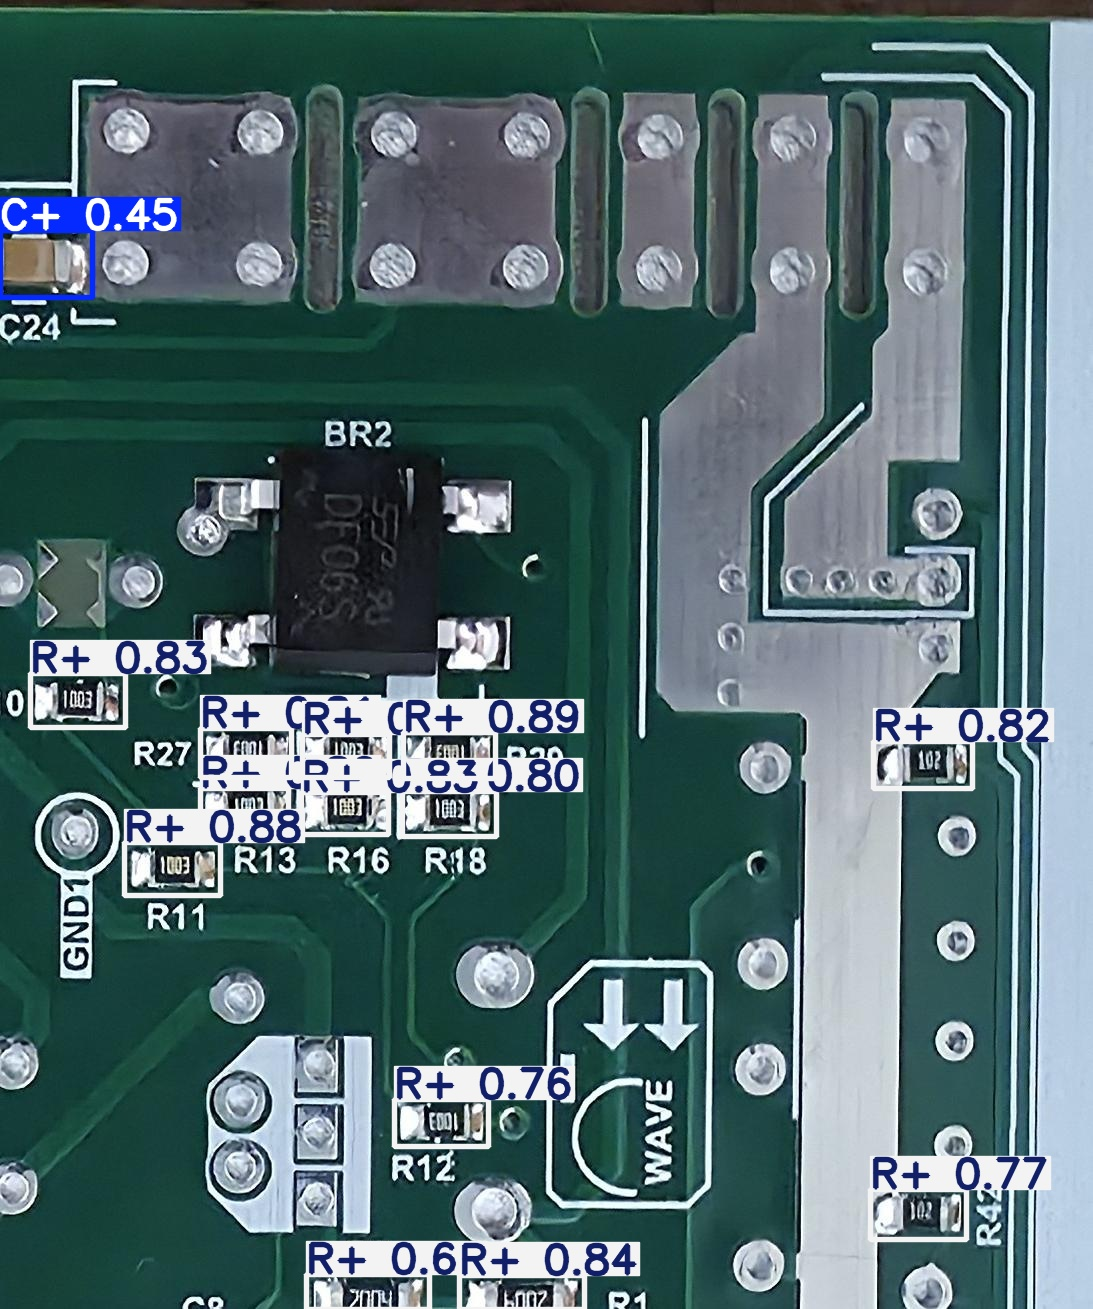

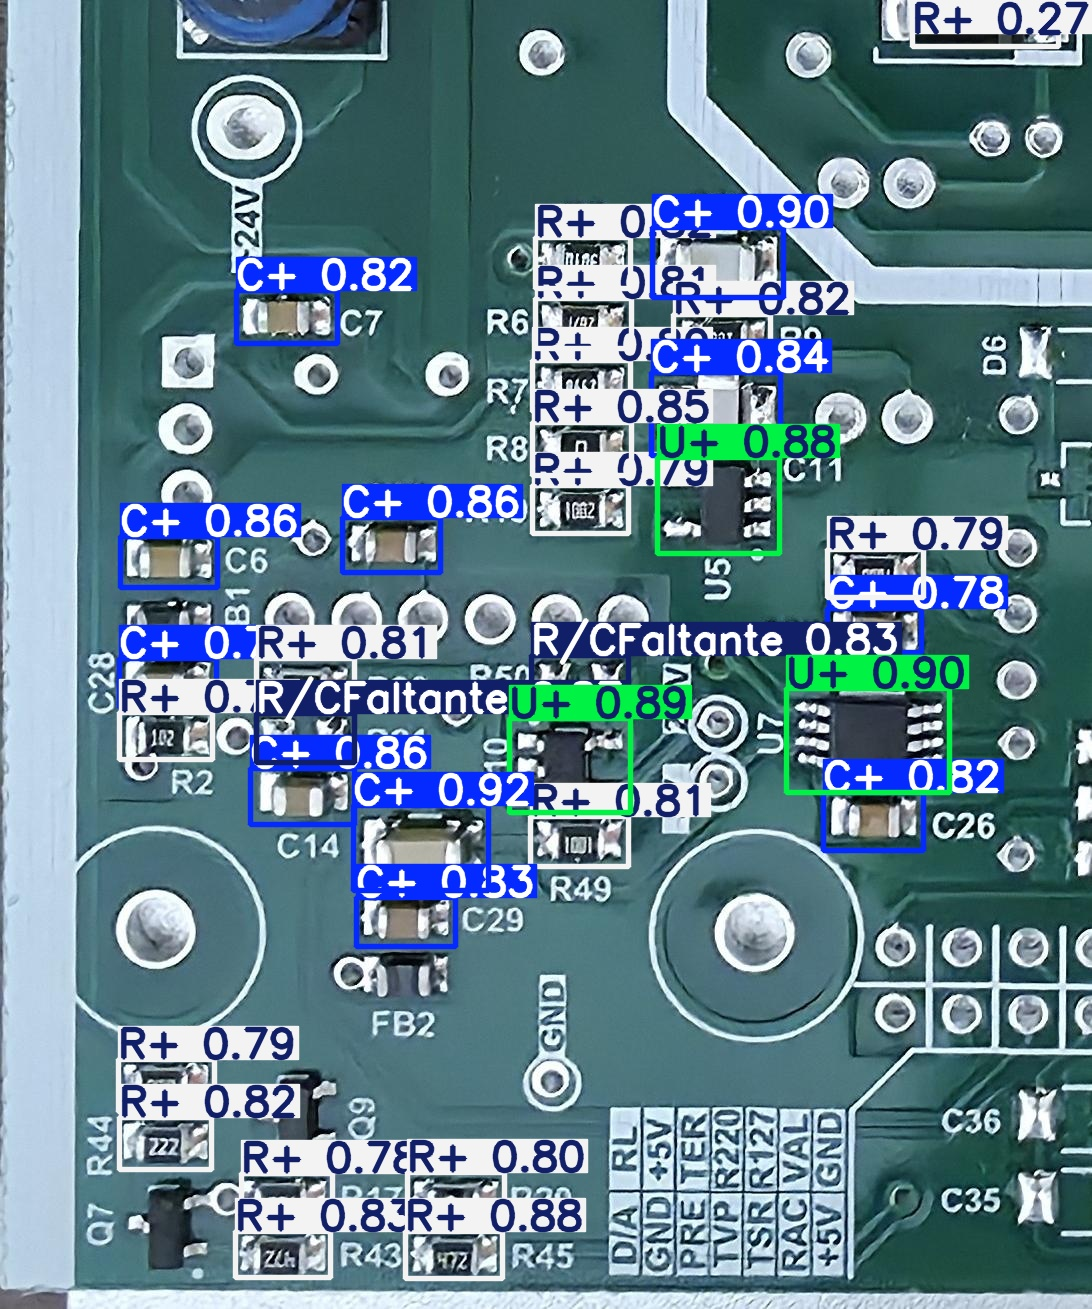

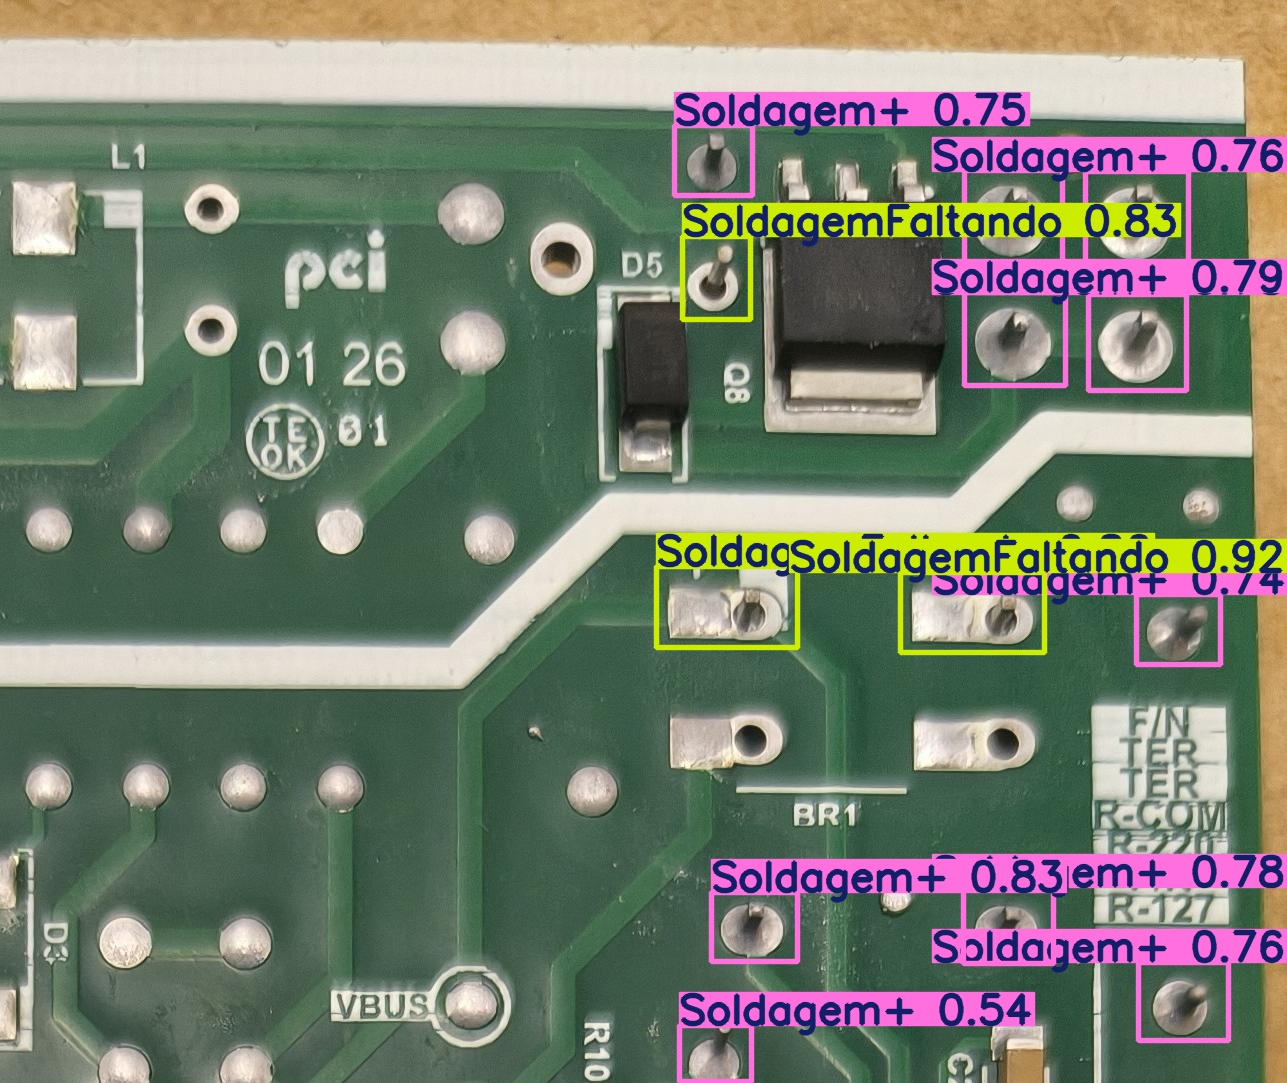

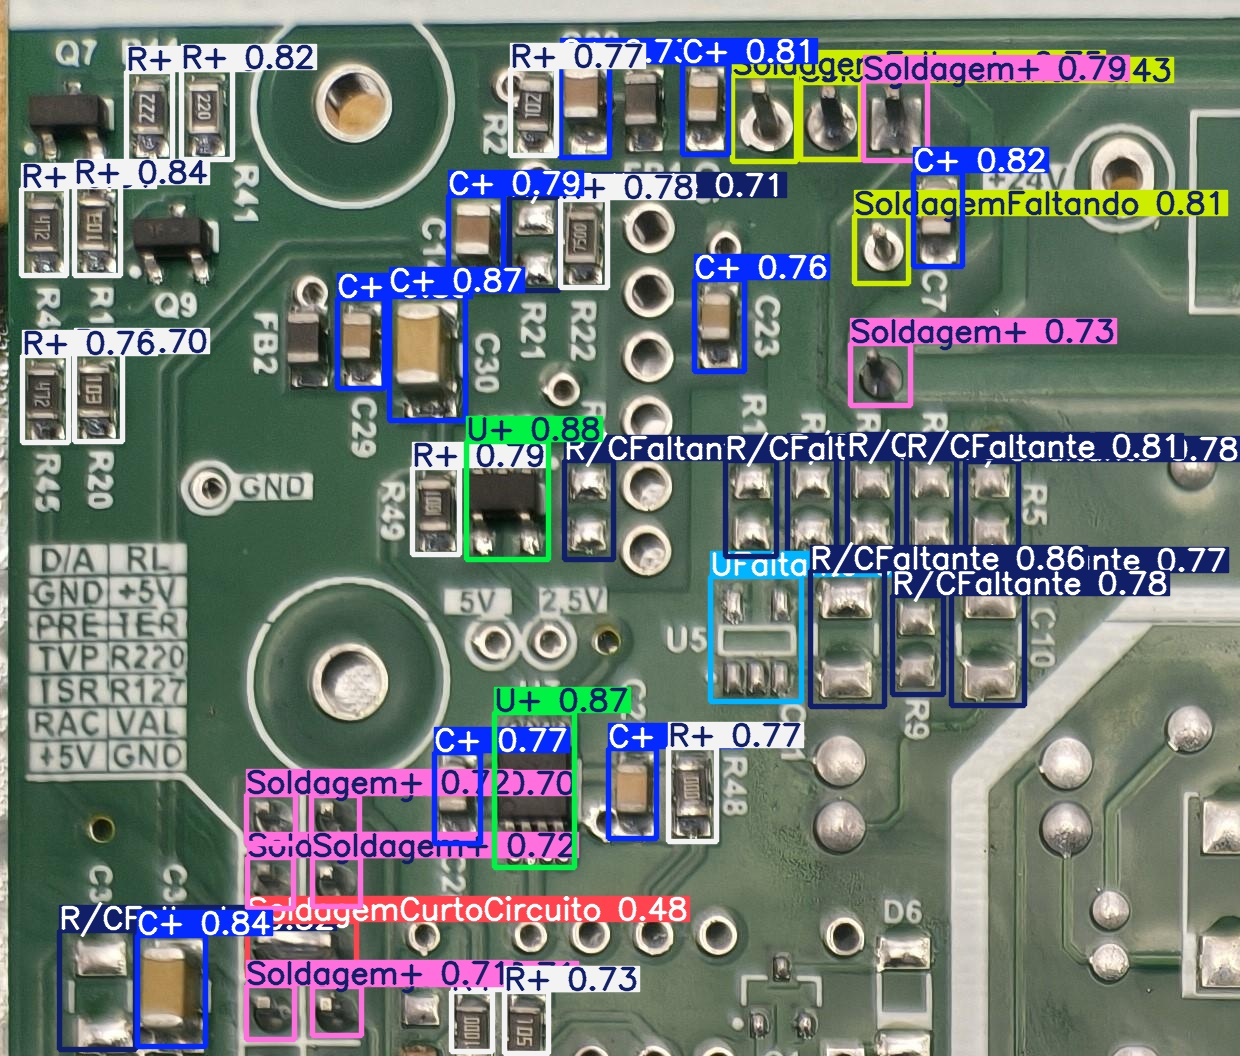

In [6]:
import glob
from IPython.display import Image, display

for image_path in glob.glob('runs/detect/predict/*.jpg')[:30]:
    display(Image(filename=image_path, height=400))
    print('\n')